In [1]:
import pandas as pd

#creating dataframes of all the sources 
df1 = pd.read_csv('1 Monitoring locations (1).csv')
df2 = pd.read_csv('2024 W1 spring-Central (1).csv')
df3 = pd.read_csv('2024 W1 spring-Cycleways (2).csv')
df4 = pd.read_csv('2024 W1 spring-Inner-Part1 (1).csv')
df5 = pd.read_csv('2024 W1 spring-Inner-Part2 (1).csv')
df6 = pd.read_csv('2024 W1 spring-Outer (1).csv')
df7 = pd.read_csv('2024 W2 autumn-Cycleways (1).csv')

#combining all the dataframes from 2024 into one
df_union = pd.concat([df2,df3,df4,df5,df6,df7] , ignore_index = True)

#Adding monitoring location details into the dataframe
df = df_union.merge(df1 ,left_on = 'SiteID' ,right_on = 'Site ID', how = 'left')

df.head(5)

,Wave,SiteID,Date,Weather,Time,Day,Round,Direction,Path,Mode,...,Location description,Borough,Functional area for monitoring,Road type,Is it on the strategic CIO panel?,Old site ID (legacy),Easting (UK Grid),Northing (UK Grid),Latitude,Longitude
0,2024 W1 spring,ML0001,16/07/2024,Dry,06:00:00,Weekday,A,Northbound,Carriageway,Cargo bikes,...,Millbank (south of Thorney Street),Westminster,01 Central,01 A Road,1.0,CENCY001,530251.49,178742.45,51.492628,-0.125204
1,2024 W1 spring,ML0001,16/07/2024,Dry,06:15:00,Weekday,A,Northbound,Carriageway,Cargo bikes,...,Millbank (south of Thorney Street),Westminster,01 Central,01 A Road,1.0,CENCY001,530251.49,178742.45,51.492628,-0.125204
2,2024 W1 spring,ML0001,16/07/2024,Dry,06:30:00,Weekday,A,Northbound,Carriageway,Cargo bikes,...,Millbank (south of Thorney Street),Westminster,01 Central,01 A Road,1.0,CENCY001,530251.49,178742.45,51.492628,-0.125204
3,2024 W1 spring,ML0001,16/07/2024,Dry,06:45:00,Weekday,A,Northbound,Carriageway,Cargo bikes,...,Millbank (south of Thorney Street),Westminster,01 Central,01 A Road,1.0,CENCY001,530251.49,178742.45,51.492628,-0.125204
4,2024 W1 spring,ML0001,16/07/2024,Dry,07:00:00,Weekday,A,Northbound,Carriageway,Cargo bikes,...,Millbank (south of Thorney Street),Westminster,01 Central,01 A Road,1.0,CENCY001,530251.49,178742.45,51.492628,-0.125204


In [2]:
#listing out all the columns
df.columns.tolist()

['Wave',
 'SiteID',
 'Date',
 'Weather',
 'Time',
 'Day',
 'Round',
 'Direction',
 'Path',
 'Mode',
 'Count',
 'Site ID',
 'Location description',
 'Borough',
 'Functional area for monitoring',
 'Road type',
 'Is it on the strategic CIO panel?',
 'Old site ID (legacy)',
 'Easting (UK Grid)',
 'Northing (UK Grid)',
 'Latitude',
 'Longitude']

In [3]:
#no of rows and columns in the dataset
df.shape


(2352512, 22)

In [4]:
#dropping columns which are not relevant 
df.drop(columns=['Is it on the strategic CIO panel?','Old site ID (legacy)','Easting (UK Grid)','Northing (UK Grid)','Latitude','Longitude','Site ID'],inplace = True)


In [5]:
df.columns.tolist()

['Wave',
 'SiteID',
 'Date',
 'Weather',
 'Time',
 'Day',
 'Round',
 'Direction',
 'Path',
 'Mode',
 'Count',
 'Location description',
 'Borough',
 'Functional area for monitoring',
 'Road type']

In [6]:
df['Borough'].value_counts()

Borough
Westminster             221696
Lambeth                 192768
Southwark               183424
Camden                  151296
Wandsworth              136960
Tower Hamlets           118912
Islington               113152
Hackney                  94208
Kensington & Chelsea     73472
Lewisham                 71936
Hammersmith & Fulham     71936
City of London           69632
Merton                   65280
Ealing                   58368
Waltham Forest           53248
Newham                   50176
Greenwich                47872
Bromley                  47616
Croydon                  47616
Hillingdon               46080
Haringey                 43776
Richmond upon Thames     42752
Brent                    41984
Enfield                  40704
Hounslow                 38400
Redbridge                37888
Kingston upon Thames     32256
Sutton                   30720
Barnet                   29696
Bexley                   27136
Harrow                   25600
Havering                 25088


In [7]:
#Only keeping Kingston Upon thames and Sutton boroughs data , because their population resembles exeter's population 

df = df[df['Borough'].isin(['Kingston upon Thames','Sutton'])]

In [8]:
df['Borough'].value_counts()

Borough
Kingston upon Thames    32256
Sutton                  30720
Name: count, dtype: int64

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 62976 entries, 403968 to 2296319
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   Wave                            62976 non-null  object
 1   SiteID                          62976 non-null  object
 2   Date                            62976 non-null  object
 3   Weather                         62976 non-null  object
 4   Time                            62976 non-null  object
 5   Day                             62976 non-null  object
 6   Round                           62976 non-null  object
 7   Direction                       62976 non-null  object
 8   Path                            57344 non-null  object
 9   Mode                            62976 non-null  object
 10  Count                           62976 non-null  int64 
 11  Location description            62976 non-null  object
 12  Borough                         62976 non-nu

In [10]:
#Converting data type of date and time from object to date time
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce') 
df['Time']=pd.to_datetime(df['Time'],format ='%H:%M:%S' , errors='coerce')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 62976 entries, 403968 to 2296319
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   Wave                            62976 non-null  object        
 1   SiteID                          62976 non-null  object        
 2   Date                            62976 non-null  datetime64[ns]
 3   Weather                         62976 non-null  object        
 4   Time                            62976 non-null  datetime64[ns]
 5   Day                             62976 non-null  object        
 6   Round                           62976 non-null  object        
 7   Direction                       62976 non-null  object        
 8   Path                            57344 non-null  object        
 9   Mode                            62976 non-null  object        
 10  Count                           62976 non-null  int64         
 11  

In [12]:
#Changing the column names to lower case 
df.columns = df.columns.str.replace(" ", "_").str.lower()

In [13]:
df.columns.to_list()

['wave',
 'siteid',
 'date',
 'weather',
 'time',
 'day',
 'round',
 'direction',
 'path',
 'mode',
 'count',
 'location_description',
 'borough',
 'functional_area_for_monitoring',
 'road_type']

In [14]:
# Fetching %missing values in columns
def missing_report(df):
    missing_df = (df.isnull().sum()/len(df)).rename_axis('columns').to_frame('missing_percentage').reset_index()
    missing_df['missing_percentage'] = missing_df['missing_percentage'] * 100
    missing_df['type'] = missing_df['columns'].apply(lambda col: str(df[col].dtypes))
    return missing_df.sort_values(by = 'missing_percentage', ascending=False)
missing_report(df)

,columns,missing_percentage,type
8,path,8.943089,object
0,wave,0.000000,object
1,siteid,0.000000,object
2,date,0.000000,datetime64[ns]
3,weather,0.000000,object
4,time,0.000000,datetime64[ns]
5,day,0.000000,object
6,round,0.000000,object
7,direction,0.000000,object
9,mode,0.000000,object


In [15]:
# All values in Path column and its count
df['path'].value_counts(dropna=False)

path
Carriageway                15360
Pavement - Southbound       7680
Pavement - Eastbound        7680
Pavement - Westbound        7680
Pavement - Northbound       7168
NaN                         5632
Cycle lane - Northbound     2560
Cycle lane - Southbound     2560
Shared path                 2560
Cycle lane - Eastbound      2048
Cycle lane - Westbound      2048
Name: count, dtype: int64

In [16]:
#Replacing all null values to none
df['path'] = df['path'].replace(['n/a', 'N/A', 'NA', '', ' ','NaN'], 'none')

df['path'] = df['path'].fillna('none')

In [17]:
def missing_report(df):
    missing_df = (df.isnull().sum()/len(df)).rename_axis('columns').to_frame('missing_percentage').reset_index()
    missing_df['missing_percentage'] = missing_df['missing_percentage'] * 100
    missing_df['type'] = missing_df['columns'].apply(lambda col: str(df[col].dtypes))
    return missing_df.sort_values(by = 'missing_percentage', ascending=False)
missing_report(df)

,columns,missing_percentage,type
0,wave,0.0,object
1,siteid,0.0,object
2,date,0.0,datetime64[ns]
3,weather,0.0,object
4,time,0.0,datetime64[ns]
5,day,0.0,object
6,round,0.0,object
7,direction,0.0,object
8,path,0.0,object
9,mode,0.0,object


In [18]:
#checking duplicate values
df[df.duplicated()]

,wave,siteid,date,weather,time,day,round,direction,path,mode,count,location_description,borough,functional_area_for_monitoring,road_type


In [19]:
#descriptive analysis on the count metric

df['count'].describe()

count    62976.000000
mean         1.037078
std          3.874150
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        230.000000
Name: count, dtype: float64

In [20]:
#Understanding the max_value 230 in depth 

df[df['count']== 230]

,wave,siteid,date,weather,time,day,round,direction,path,mode,count,location_description,borough,functional_area_for_monitoring,road_type
2284773,2024 W1 spring,ML1422,2024-06-20,Dry,1900-01-01 15:15:00,Weekday,A,Eastbound,Shared path,Pedestrians,230,Church Fields Recreation Ground,Kingston upon Thames,03 Outer,05 Motor vehicle-free


In [21]:
df[(df['mode'] =='Pedestrians') & (df['location_description'] =='Church Fields Recreation Ground') & (df['time'] >'1900-01-01 14:45:00') & (df['time'] <'1900-01-01 15:45:00')]


,wave,siteid,date,weather,time,day,round,direction,path,mode,count,location_description,borough,functional_area_for_monitoring,road_type
2284772,2024 W1 spring,ML1422,2024-06-20,Dry,1900-01-01 15:00:00,Weekday,A,Eastbound,Shared path,Pedestrians,0,Church Fields Recreation Ground,Kingston upon Thames,03 Outer,05 Motor vehicle-free
2284773,2024 W1 spring,ML1422,2024-06-20,Dry,1900-01-01 15:15:00,Weekday,A,Eastbound,Shared path,Pedestrians,230,Church Fields Recreation Ground,Kingston upon Thames,03 Outer,05 Motor vehicle-free
2284774,2024 W1 spring,ML1422,2024-06-20,Dry,1900-01-01 15:30:00,Weekday,A,Eastbound,Shared path,Pedestrians,1,Church Fields Recreation Ground,Kingston upon Thames,03 Outer,05 Motor vehicle-free
2285028,2024 W1 spring,ML1422,2024-06-20,Dry,1900-01-01 15:00:00,Weekday,A,Westbound,Shared path,Pedestrians,21,Church Fields Recreation Ground,Kingston upon Thames,03 Outer,05 Motor vehicle-free
2285029,2024 W1 spring,ML1422,2024-06-20,Dry,1900-01-01 15:15:00,Weekday,A,Westbound,Shared path,Pedestrians,93,Church Fields Recreation Ground,Kingston upon Thames,03 Outer,05 Motor vehicle-free
2285030,2024 W1 spring,ML1422,2024-06-20,Dry,1900-01-01 15:30:00,Weekday,A,Westbound,Shared path,Pedestrians,6,Church Fields Recreation Ground,Kingston upon Thames,03 Outer,05 Motor vehicle-free


In [22]:
# we don't need pedestrians data , it is not relevant and doesn't add any insight to the project

df = df[df['mode'] != 'Pedestrians']

In [23]:
df['mode'].value_counts()

mode
Cargo bikes            14336
Conventional cycles    14336
E-scooters             14336
Female cyclists         1536
Male cyclists           1536
Unknown cyclists        1536
Cycle hire bikes         512
Private cycles           512
Name: count, dtype: int64

In [24]:
# Doing the descriptive analysis on the count metric again after filtering pedestrians out

df['count'].describe()

count    48640.000000
mean         0.426542
std          1.652427
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         44.000000
Name: count, dtype: float64

In [25]:
df['day'].value_counts()

day
Weekday    48640
Name: count, dtype: int64

In [26]:
df['weather'].value_counts()

weather
Dry    41942
Wet     3956
dry     1638
DRY      768
WET      216
wet      120
Name: count, dtype: int64

In [27]:
# Cleaning the categories
df['weather'] = df['weather'].str.lower().str.strip()
df['weather'] = df['weather'].replace({
    'dry': 'Dry',
    'wet': 'Wet'
})

In [28]:
df['weather'].value_counts()

weather
Dry    44348
Wet     4292
Name: count, dtype: int64

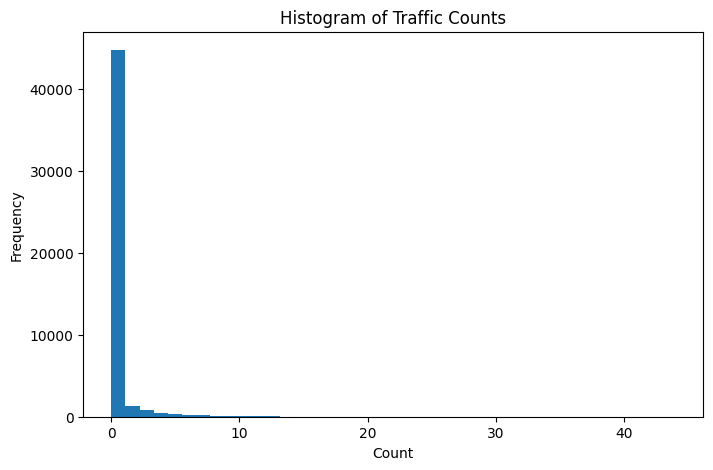

In [29]:
# Plotting histogram to understand the distribution of the count metric
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['count'], bins=40)
plt.xlabel('Count')
plt.ylabel('Frequency')
plt.title('Histogram of Traffic Counts')
plt.show()

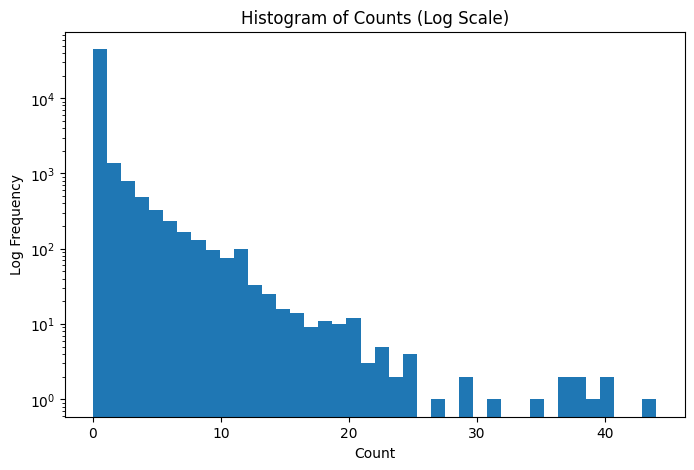

In [30]:
#using log scale to visualise the distribution better
plt.figure(figsize=(8,5))
plt.hist(df['count'], bins=40, log=True)
plt.xlabel('Count')
plt.ylabel('Log Frequency')
plt.title('Histogram of Counts (Log Scale)')
plt.show()

In [31]:
# Descriptive analysis on the count metric by mode of transport
df.groupby('mode')['count'].agg(['mean', 'median', 'std', 'min', 'max', 'count'])


,mean,median,std,min,max,count
mode,,,,,,
Cargo bikes,0.004255,0.0,0.066157,0,2,14336
Conventional cycles,0.650181,0.0,1.955106,0,44,14336
Cycle hire bikes,0.011719,0.0,0.124571,0,2,512
E-scooters,0.021973,0.0,0.219407,0,15,14336
Female cyclists,1.134766,1.0,1.386088,0,12,1536
Male cyclists,4.686198,4.0,4.068209,0,29,1536
Private cycles,3.972656,3.0,3.906845,0,25,512
Unknown cyclists,0.044922,0.0,0.242006,0,3,1536


<Figure size 1200x600 with 0 Axes>

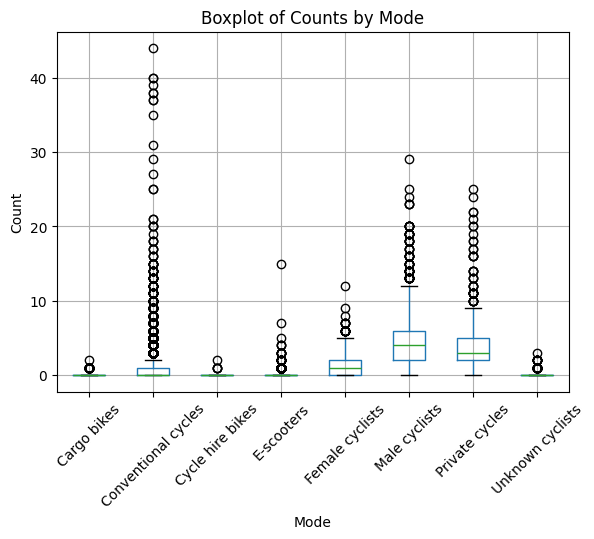

In [32]:
plt.figure(figsize=(12,6))
df.boxplot(column='count', by='mode', rot=45)
plt.title('Boxplot of Counts by Mode')
plt.suptitle('')   
plt.xlabel('Mode')
plt.ylabel('Count')
plt.show()

In [33]:
#Descriptive statistic of count by borough

df.groupby('borough')['count'].agg(['mean', 'median', 'std', 'min', 'max', 'count'])


,mean,median,std,min,max,count
borough,,,,,,
Kingston upon Thames,0.684570,0.0,2.174916,0,44,25600
Sutton,0.139844,0.0,0.593724,0,15,23040


In [34]:
#cleaned data csv for analysis on tableau
df.to_csv('mobility_data.csv', index=False)

In [35]:
#Creating a category of path_group 

def assign_path_group(path):
    if pd.isna(path):
        return 'none'
    path_lower = str(path).lower()
    
    if 'carriageway' in path_lower:
        return 'Carriageway'
    elif 'cycle lane' in path_lower:
        return 'cycle lane'
    elif 'pavement' in path_lower:
        return 'pavement'
    elif 'shared path' in path_lower:
        return 'Shared path'
    elif path_lower == 'none':
        return 'none'
    else:
        return 'other'  

df.loc[:,'path_group'] = df['path'].apply(assign_path_group)


In [36]:
df.columns.to_list()

['wave',
 'siteid',
 'date',
 'weather',
 'time',
 'day',
 'round',
 'direction',
 'path',
 'mode',
 'count',
 'location_description',
 'borough',
 'functional_area_for_monitoring',
 'road_type',
 'path_group']

In [37]:
df.loc[:,"hour"] = df["time"].dt.hour

In [38]:
df.columns.to_list()

['wave',
 'siteid',
 'date',
 'weather',
 'time',
 'day',
 'round',
 'direction',
 'path',
 'mode',
 'count',
 'location_description',
 'borough',
 'functional_area_for_monitoring',
 'road_type',
 'path_group',
 'hour']

In [39]:
df.head(5)

,wave,siteid,date,weather,time,day,round,direction,path,mode,count,location_description,borough,functional_area_for_monitoring,road_type,path_group,hour
403968,2024 W1 spring,ML1799,2024-05-14,Wet,1900-01-01 06:00:00,Weekday,A,Northbound,none,Cycle hire bikes,0,Penrhyn Road,Kingston upon Thames,03 Outer,01 A Road,none,6
403969,2024 W1 spring,ML1799,2024-05-14,Wet,1900-01-01 06:15:00,Weekday,A,Northbound,none,Cycle hire bikes,0,Penrhyn Road,Kingston upon Thames,03 Outer,01 A Road,none,6
403970,2024 W1 spring,ML1799,2024-05-14,Wet,1900-01-01 06:30:00,Weekday,A,Northbound,none,Cycle hire bikes,0,Penrhyn Road,Kingston upon Thames,03 Outer,01 A Road,none,6
403971,2024 W1 spring,ML1799,2024-05-14,Wet,1900-01-01 06:45:00,Weekday,A,Northbound,none,Cycle hire bikes,0,Penrhyn Road,Kingston upon Thames,03 Outer,01 A Road,none,6
403972,2024 W1 spring,ML1799,2024-05-14,Wet,1900-01-01 07:00:00,Weekday,A,Northbound,none,Cycle hire bikes,0,Penrhyn Road,Kingston upon Thames,03 Outer,01 A Road,none,7


In [40]:
#creating a new coloumn for time period
def create_time_period(hour):
    if hour < 6:
        return 'night'
    elif 6 <= hour < 9:
        return 'morning_rush'  # Peak around 7-8am 
    elif 9 <= hour < 15:
        return 'midday' 
    elif 15 <= hour < 19:
        return 'evening_rush'  # Peak around 5-6pm 
    else:
        return 'night' 


df.loc[:,'time_period'] = df['hour'].apply(create_time_period)



In [41]:
df.head()

,wave,siteid,date,weather,time,day,round,direction,path,mode,count,location_description,borough,functional_area_for_monitoring,road_type,path_group,hour,time_period
403968,2024 W1 spring,ML1799,2024-05-14,Wet,1900-01-01 06:00:00,Weekday,A,Northbound,none,Cycle hire bikes,0,Penrhyn Road,Kingston upon Thames,03 Outer,01 A Road,none,6,morning_rush
403969,2024 W1 spring,ML1799,2024-05-14,Wet,1900-01-01 06:15:00,Weekday,A,Northbound,none,Cycle hire bikes,0,Penrhyn Road,Kingston upon Thames,03 Outer,01 A Road,none,6,morning_rush
403970,2024 W1 spring,ML1799,2024-05-14,Wet,1900-01-01 06:30:00,Weekday,A,Northbound,none,Cycle hire bikes,0,Penrhyn Road,Kingston upon Thames,03 Outer,01 A Road,none,6,morning_rush
403971,2024 W1 spring,ML1799,2024-05-14,Wet,1900-01-01 06:45:00,Weekday,A,Northbound,none,Cycle hire bikes,0,Penrhyn Road,Kingston upon Thames,03 Outer,01 A Road,none,6,morning_rush
403972,2024 W1 spring,ML1799,2024-05-14,Wet,1900-01-01 07:00:00,Weekday,A,Northbound,none,Cycle hire bikes,0,Penrhyn Road,Kingston upon Thames,03 Outer,01 A Road,none,7,morning_rush


In [42]:
#creating a copy for modelling
df_demand = df.copy()

In [43]:
#aggregate data across all modes to get total prediction
df_agg = df_demand.groupby(
    ["time","weather","road_type","path_group","direction","location_description","hour",'borough','day','time_period']
)["count"].sum().reset_index()

In [44]:
df_agg.head()

,time,weather,road_type,path_group,direction,location_description,hour,borough,day,time_period,count
0,1900-01-01 06:00:00,Dry,01 A Road,Carriageway,Eastbound,Coombe Lane West,6,Kingston upon Thames,Weekday,morning_rush,1
1,1900-01-01 06:00:00,Dry,01 A Road,Carriageway,Eastbound,Kingston Road,6,Kingston upon Thames,Weekday,morning_rush,0
2,1900-01-01 06:00:00,Dry,01 A Road,Carriageway,Eastbound,Pound Street,6,Sutton,Weekday,morning_rush,2
3,1900-01-01 06:00:00,Dry,01 A Road,Carriageway,Eastbound,Reigate Avenue,6,Sutton,Weekday,morning_rush,1
4,1900-01-01 06:00:00,Dry,01 A Road,Carriageway,Northbound,Kingston Hill,6,Kingston upon Thames,Weekday,morning_rush,1


In [45]:
#csv file of data used for modelling
df.to_csv('aggregated_data_for_modelling.csv', index=False)

In [46]:
#applying OLS statsmodel for understanding significance
import statsmodels.formula.api as smf

model = smf.ols(
    formula="count ~ C(weather) + C(time_period) + C(road_type) + C(path_group) +C(direction) +C(location_description)",
    data=df_agg
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  count   R-squared:                       0.605
Model:                            OLS   Adj. R-squared:                  0.603
Method:                 Least Squares   F-statistic:                     309.4
Date:                Sun, 14 Dec 2025   Prob (F-statistic):               0.00
Time:                        17:51:34   Log-Likelihood:                -26416.
No. Observations:               11392   AIC:                         5.295e+04
Df Residuals:                   11335   BIC:                         5.337e+04
Df Model:                          56                                         
Covariance Type:            nonrobust                                         
                                                                    coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------

In [47]:
#testing model without location description

model = smf.ols(
    formula="count ~ C(weather) + C(time_period) + C(road_type) + C(path_group) +C(direction)",
    data=df_agg
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  count   R-squared:                       0.280
Model:                            OLS   Adj. R-squared:                  0.279
Method:                 Least Squares   F-statistic:                     294.9
Date:                Sun, 14 Dec 2025   Prob (F-statistic):               0.00
Time:                        17:51:47   Log-Likelihood:                -29830.
No. Observations:               11392   AIC:                         5.969e+04
Df Residuals:                   11376   BIC:                         5.981e+04
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

In [49]:
#Applying linear regression model to the dataset 


import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np




# Define target and features

y = df_agg['count']  # demand
X = df_agg[['weather', 'time_period', 'road_type', 'path_group', 'direction','location_description']]


#One-hot encode categoricals

categorical_features = ['weather', 'time_period', 'road_type', 'path_group', 'direction','location_description']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ],
    remainder='drop'
)


#Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


#predictive model

model = LinearRegression()

# Transform + fit
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

model.fit(X_train_transformed, y_train)


#Predictions

y_pred = model.predict(X_test_transformed)


# 7. Evaluation

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model Performance:")
print("RMSE:", rmse)
print("MAE:", mae)
print("R²:", r2)


Model Performance:
RMSE: 2.5104139932378104
MAE: 1.3911733827623118
R²: 0.5798086218407459


Training Random Forest...
✓ Training complete!

RANDOM FOREST MODEL PERFORMANCE

Training Set:
  RMSE: 1.9267
  MAE:  1.0570
  R²:   0.7593

Test Set:
  RMSE: 1.9674
  MAE:  1.0886
  R²:   0.7419

Overfitting Check:
  R² difference (train - test): 0.0174
 Model generalizes well

FEATURE IMPORTANCE (Top 10)
                                              feature  importance
44       cat__location_description_London Road (east)    0.436298
10                               cat__path_group_none    0.159887
11                           cat__path_group_pavement    0.052367
2                       cat__time_period_morning_rush    0.044610
56  cat__location_description_Thames Path (Lower H...    0.041488
34               cat__location_description_Kings Road    0.040503
1                             cat__time_period_midday    0.035007
14                           cat__direction_Westbound    0.029425
53            cat__location_description_Richmond Road    0.021124
3                              c

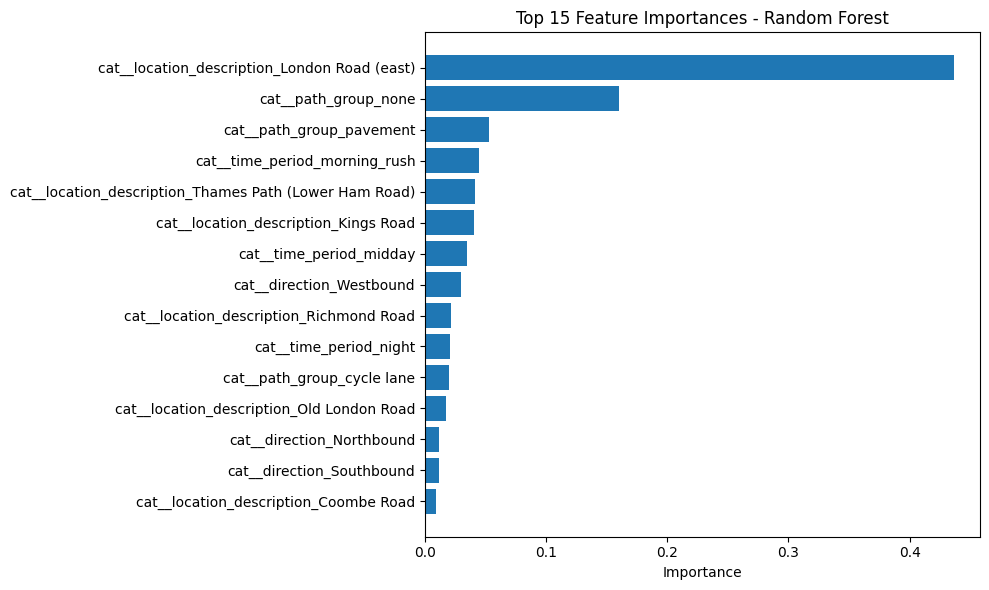

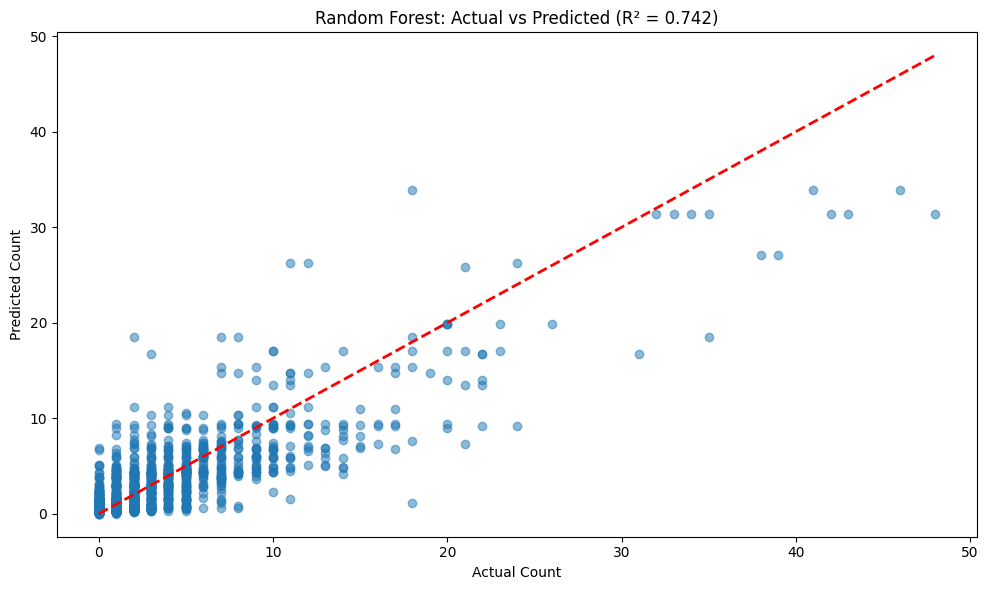

In [50]:
#Applying Random forest model to test its accuracy on skewed data

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt


# Define target and features

y = df_agg['count']  
X = df_agg[['weather', 'time_period', 'road_type', 'path_group', 'direction','location_description']]


# One-hot encode categoricals

categorical_features = ['weather', 'time_period', 'road_type', 'path_group', 'direction','location_description']
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ],
    remainder='drop'
)


# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


#Transform data

X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)


#Build Random Forest model

rf_model = RandomForestRegressor(
    n_estimators=100,      # number of trees
    max_depth=10,          # prevent overfitting
    min_samples_split=5,   # minimum samples to split
    min_samples_leaf=2,    # minimum samples per leaf
    random_state=42,
    n_jobs=-1              # use all CPU cores
)

# Fit the model
print("Training Random Forest...")
rf_model.fit(X_train_transformed, y_train)
print("✓ Training complete!")


# 6. Predictions
y_pred_train = rf_model.predict(X_train_transformed)
y_pred_test = rf_model.predict(X_test_transformed)


#Evaluation

print("\n" + "="*60)
print("RANDOM FOREST MODEL PERFORMANCE")
print("="*60)

# Training performance
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
train_mae = mean_absolute_error(y_train, y_pred_train)
train_r2 = r2_score(y_train, y_pred_train)

print("\nTraining Set:")
print(f"  RMSE: {train_rmse:.4f}")
print(f"  MAE:  {train_mae:.4f}")
print(f"  R²:   {train_r2:.4f}")

# Test performance
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
test_mae = mean_absolute_error(y_test, y_pred_test)
test_r2 = r2_score(y_test, y_pred_test)

print("\nTest Set:")
print(f"  RMSE: {test_rmse:.4f}")
print(f"  MAE:  {test_mae:.4f}")
print(f"  R²:   {test_r2:.4f}")

# Check for overfitting
print(f"\nOverfitting Check:")
print(f"  R² difference (train - test): {train_r2 - test_r2:.4f}")
if train_r2 - test_r2 > 0.1:
    print("  Model might be overfitting (consider reducing max_depth)")
else:
    print(" Model generalizes well")


# Feature Importance

print("\n" + "="*60)
print("FEATURE IMPORTANCE (Top 10)")
print("="*60)

# Get feature names after one-hot encoding
feature_names = preprocessor.get_feature_names_out()
importances = rf_model.feature_importances_

# Create DataFrame and sort
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print(feature_importance_df.head(10))




# Plot feature importance
plt.figure(figsize=(10, 6))
top_features = feature_importance_df.head(15)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances - Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Plot actual vs predicted
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_test, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Count')
plt.ylabel('Predicted Count')
plt.title(f'Random Forest: Actual vs Predicted (R² = {test_r2:.3f})')
plt.tight_layout()
plt.show()

print("\n" + "="*60)